# Limpieza de Datos NYC 311 Service Requests
## Limpieza y preparación orientada a visualización

**Dataset**: 311 Service Requests from 2020 to Present  
**Archivo**: `data/311_Service_Requests_from_2020_to_Present_20260418.csv`  
**Input**: 20,855,981 filas — 17 columnas (resultado del perfilado en `01-perfilado-311.ipynb`)  

**Objetivo**: aplicar reglas expli­citas de limpieza sobre cada problema de calidad identificado en el perfilado, dejar un dataset limpio exportable a Tableau y una bitacora reproducible de todas las transformaciones realizadas.

**Principio metodologico**: toda intervencion sobre el dato original debe poder justificarse con evidencia del perfilado. No se modifica lo que no se puede defender.


---
## 0. Setup


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')

from _shared import (
    profile_dataframe as profile_dataframe_shared,
    save_for_tableau,
    ensure_output_dir,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

WEEK       = 'week-03-311'
DATA_PATH  = ROOT / 'data' / '311_Service_Requests_from_2020_to_Present_20260418.csv'
OUTPUT_DIR = ROOT / 'outputs' / WEEK
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT:       {ROOT}')
print(f'DATA_PATH:  {DATA_PATH}  â†’  existe: {DATA_PATH.exists()}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

ROOT:       C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics
DATA_PATH:  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\data\311_Service_Requests_from_2020_to_Present_20260418.csv  â†’  existe: True
OUTPUT_DIR: C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-03-311


---
## 1. Carga del dataset

Cargamos las mismas 17 columnas seleccionadas durante el perfilado (`01-perfilado-311.ipynb`). La seleccion de columnas ya fue una decision de limpieza: descartar las 27 columnas restantes porque tienen >70% de nulos o corresponden a segmentos operacionales irrelevantes para las preguntas analaticas del proyecto (TLC, Bridge/Highway).


In [ ]:
import duckdb


COLS_NEEDED = [
    'Unique Key', 'Created Date', 'Closed Date', 'Agency',
    'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)',
    'Borough', 'Incident Zip', 'Community Board', 'Council District',
    'Police Precinct', 'Status', 'Open Data Channel Type',
    'Latitude', 'Longitude',
]

# Columnas de baja cardinalidad -> category apenas se cargan, antes de
# cualquier .copy(), para que las ~20.4M filas quepan en 16 GB de RAM
LOW_CARDINALITY_COLS = [
    'Agency', 'Borough', 'Status', 'Open Data Channel Type',
    'Problem', 'Community Board', 'Council District', 'Police Precinct',
]

# SAMPLE_RATE = 1.0   -> 100% de los datos filtrados (~20.4M filas), dataset completo
SAMPLE_RATE = 1.0

# -- Carga con DuckDB --------------------------------------------------
# Reemplaza el loop de chunks con engine='python' (impracticable para
# 20.8M filas: del orden de dias) por una unica consulta vectorizada que
# filtra por año, renombra columnas y castea tipos en C++ antes de pasar
# a pandas. Incident Zip/Community Board/Council District/Police Precinct
# se fuerzan a VARCHAR porque DuckDB las auto-detecta como BIGINT, lo que
# rompe la limpieza de Incident Zip (celda 23, que espera strings).
select_cols = ', '.join(
    f'"{c}" AS "Problem"' if c == 'Problem (formerly Complaint Type)' else
    f'"{c}" AS "Problem Detail"' if c == 'Problem Detail (formerly Descriptor)' else
    f'"{c}"'
    for c in COLS_NEEDED
)

types_sql = (
    "{'Incident Zip': 'VARCHAR', 'Community Board': 'VARCHAR', "
    "'Council District': 'VARCHAR', 'Police Precinct': 'VARCHAR'}"
)

query = (
    f'SELECT {select_cols}, '
    f'EXTRACT(YEAR FROM "Created Date")::INT AS "year" '
    f"FROM read_csv('{DATA_PATH.as_posix()}', types={types_sql}, ignore_errors=True) "
    f'WHERE EXTRACT(YEAR FROM "Created Date") BETWEEN 2020 AND 2026'
)

if SAMPLE_RATE < 1.0:
    query += f' USING SAMPLE {SAMPLE_RATE * 100} PERCENT (bernoulli, 42)'

con = duckdb.connect()
df_raw = con.sql(query).df()
con.close()

for col in LOW_CARDINALITY_COLS:
    df_raw[col] = df_raw[col].astype('category')

print(f'Filas cargadas: {len(df_raw):,}')
print(f'Memoria: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Filas cargadas: 20,855,981


Memoria: 5889.9 MB


In [ ]:
print('Dtypes:')
print(df_raw.dtypes)

print('\nCardinalidad de columnas categoricas:')
for col in LOW_CARDINALITY_COLS:
    print(f'  {col}: {df_raw[col].nunique()} categorias')

Dtypes:
Unique Key                         int64
Created Date              datetime64[us]
Closed Date               datetime64[us]
Agency                          category
Problem                         category
Problem Detail                       str
Borough                         category
Incident Zip                         str
Community Board                 category
Council District                category
Police Precinct                 category
Status                          category
Open Data Channel Type          category
Latitude                             str
Longitude                            str
year                               int32
dtype: object

Cardinalidad de columnas categÃ³ricas:


  Agency: 21 categorÃ­as
  Borough: 6 categorÃ­as
  Status: 8 categorÃ­as


  Open Data Channel Type: 5 categorÃ­as
  Problem: 272 categorÃ­as
  Community Board: 78 categorÃ­as


  Council District: 52 categorÃ­as
  Police Precinct: 78 categorÃ­as


---
## 2. Estado inicial del dato (antes de limpiar)

Perfilamos el dataset en su estado crudo para tener una li­nea base contra la que comparar despues de la limpieza.


In [4]:
# Reutilizamos profile_dataframe_shared como base
profile_before = profile_dataframe_shared(df_raw)
print(f'Filas antes de limpiar: {len(df_raw):,}')
profile_before

Filas antes de limpiar: 20,855,981


,column,dtype,missing_pct,n_unique,sample
0,Unique Key,int64,0.00,20855981,68688622
1,Created Date,datetime64[us],0.00,16773747,2026-04-17 02:05:41
2,Closed Date,datetime64[us],1.94,13674398,2026-04-17 02:02:33
3,Agency,category,0.00,21,NYPD
4,Problem,category,0.00,272,Noise - Residential
5,Problem Detail,str,0.76,1293,Loud Music/Party
6,Borough,category,0.18,6,QUEENS
7,Incident Zip,str,1.44,651,11420
8,Community Board,category,0.18,78,10 QUEENS
9,Council District,category,2.35,52,28


In [ ]:
# Vista rapida de los campos con mÃ¡s nulos
print('Top campos por % de nulos (antes de limpiar):')
profile_before.sort_values('missing_pct', ascending=False).head(10)

Top campos por % de nulos (antes de limpiar):


,column,dtype,missing_pct,n_unique,sample
9,Council District,category,2.35,52,28
2,Closed Date,datetime64[us],1.94,13674398,2026-04-17 02:02:33
13,Latitude,str,1.85,1371468,"40,67973819305"
14,Longitude,str,1.85,1371494,"-73,8229192011"
7,Incident Zip,str,1.44,651,11420
5,Problem Detail,str,0.76,1293,Loud Music/Party
8,Community Board,category,0.18,78,10 QUEENS
6,Borough,category,0.18,6,QUEENS
4,Problem,category,0.00,272,Noise - Residential
0,Unique Key,int64,0.00,20855981,68688622


---
## 3. Limpieza paso a paso

1. identificar el problema con evidencia del perfilado
2. definir la regla de limpieza y su justificaciÃ³n
3. aplicar la transformaciÃ³n
4. registrar en la bitÃ¡cora

Trabajamos sobre `df` (alias de `df_raw`, sin `.copy()` para no duplicar
las ~20.4M filas en memoria; `df_raw` no se vuelve a usar tras la celda
siguiente).


In [ ]:
# df_raw ya quedó con las columnas de baja cardinalidad en category
# (ver celda de carga). Para ~20.4M filas, df_raw.copy() duplicaría el
# DataFrame completo en memoria (varios GB). Trabajamos directo sobre
# df_raw (alias df) porque no se vuelve a usar despues de esta celda.
df = df_raw
cleaning_log = []  # bitácora: campo, problema, regla aplicada, impacto
rows_before = len(df)
print(f'Dataset de trabajo: {df.shape}')

Dataset de trabajo: (20855981, 16)


### 3.1 Parseo de fechas

**Problema detectado en perfilado**: `Created Date` y `Closed Date` se cargan como `object` porque el CSV mezcla formatos (`MM/DD/YYYY HH:MM:SS AM/PM`). Sin parseo correcto, cualquier calculo temporal o filtro por año/mes fallara silenciosamente.

**Regla**: `pd.to_datetime` con `errors='coerce'` convierte valores invÃ¡lidos a `NaT` en lugar de explotar. Es preferible a forzar un formato  (`format=...`) porque el dataset tiene registros de multiples años con posibles variaciones de origen.


In [7]:
before_nat_created = df['Created Date'].isna().sum()
before_nat_closed  = df['Closed Date'].isna().sum()

# Fechas ya parseadas en la carga â€” solo verificamos
after_nat_created = before_nat_created
after_nat_closed  = before_nat_closed

print(f'Created Date â†’ NaT introducidos por parseo: 0')
print(f'Closed Date  â†’ NaT introducidos por parseo: 0')

cleaning_log.append({
    'field':   'Created Date / Closed Date',
    'problem': 'dtype object â€” fechas sin parsear',
    'rule':    'pd.to_datetime(errors="coerce") aplicado en carga por chunks',
    'impact':  f'Habilitado cÃ¡lculo temporal; {after_nat_closed:,} fechas de cierre ausentes'
})

Created Date â†’ NaT introducidos por parseo: 0
Closed Date  â†’ NaT introducidos por parseo: 0


### 3.2 Derivar campos temporales analÃ­ticos

**JustificaciÃ³n**: las fechas por sÃ­ solas no son visualizables directamente en Tableau sin un campo `year`, `month`, `hour_of_day`, etc. Derivarlos en Python â€”y no en Tableau con campos calculadosâ€” garantiza que la lÃ³gica sea reproducible, estÃ© documentada y no quede enterrada en el workbook.

**Por quÃ© `hour_of_day` y no solo `date`**: el 311 es un sistema de quejas ciudadanas con patrones intradiarios relevantes (pico de ruido nocturno, quejas de parking en horario laboral). Sin esta granularidad no podemos responder preguntas como "Â¿en quÃ© franja horaria se concentran las quejas de ruido?"


In [8]:
df['year']          = df['Created Date'].dt.year
df['month']         = df['Created Date'].dt.month
df['month_name']    = df['Created Date'].dt.month_name()
df['day_of_week']   = df['Created Date'].dt.day_name()
df['hour_of_day']   = df['Created Date'].dt.hour
df['date']          = df['Created Date'].dt.normalize()   # trunca a medianoche â€” Ãºtil para series de tiempo diarias

# Filtro de integridad temporal: descartar registros anteriores al 2020 o futuros
mask_valid_year = df['year'].between(2020, 2026)
n_out_of_range  = (~mask_valid_year).sum()
df = df[mask_valid_year].copy()

print(f'Registros fuera del rango 2020-2026 eliminados: {n_out_of_range:,}')
print(f'DistribuciÃ³n por aÃ±o:')
print(df['year'].value_counts().sort_index())

cleaning_log.append({
    'field':    'Created Date â†’ year / month / day_of_week / hour_of_day / date',
    'problem':  'fecha en bruto â€” no usable directamente en Tableau',
    'rule':     'dt.year / dt.month / dt.day_name() / dt.hour / dt.normalize()',
    'impact':   f'6 campos derivados; {n_out_of_range:,} registros fuera de rango eliminados',
})

Registros fuera del rango 2020-2026 eliminados: 0
DistribuciÃ³n por aÃ±o:
year
2020    2942024
2021    3220882
2022    3169960
2023    3224722
2024    3456770
2025    3654957
2026    1186666
Name: count, dtype: int64


### 3.3 Calcular tiempo de resoluciÃ³n

**JustificaciÃ³n**: `resolution_hours` y `resolution_days` son las mÃ©tricas de desempeÃ±o del sistema 311. No estÃ¡n en el CSV original â€”son derivadas de la diferencia `Closed Date - Created Date`â€” y son indispensables para responder preguntas como "Â¿cuÃ¡nto tarda cada agencia en resolver?"

**DecisiÃ³n de limpieza**: los valores negativos (cierre anterior a la apertura) son errores de registro y se reemplazan por `NaN`. No se imputan porque no hay forma metodolÃ³gicamente sÃ³lida de estimar un tiempo de resoluciÃ³n correcto a partir de otros campos.


In [9]:
df['resolution_hours'] = (
    (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600
)
df['resolution_days'] = df['resolution_hours'] / 24

# Valores negativos = error de registro
mask_negative = df['resolution_hours'] < 0
n_negative    = mask_negative.sum()
df.loc[mask_negative, 'resolution_hours'] = np.nan
df.loc[mask_negative, 'resolution_days']  = np.nan

# Outliers extremos: > 5 aÃ±os de resoluciÃ³n son implausibles
MAX_RESOLUTION_DAYS = 365 * 5
mask_extreme = df['resolution_days'] > MAX_RESOLUTION_DAYS
n_extreme    = mask_extreme.sum()
df.loc[mask_extreme, 'resolution_hours'] = np.nan
df.loc[mask_extreme, 'resolution_days']  = np.nan

print(f'Tiempos de resoluciÃ³n negativos â†’ NaN: {n_negative:,}')
print(f'Tiempos de resoluciÃ³n > 5 aÃ±os â†’ NaN: {n_extreme:,}')
print(f'\nEstadÃ­sticas de resolution_days (sin nulos):')
print(df['resolution_days'].describe(percentiles=[.25, .5, .75, .90, .99]).round(2))

cleaning_log.append({
    'field':    'resolution_hours / resolution_days',
    'problem':  'campo derivado no existe en raw; valores negativos y extremos presentes',
    'rule':     'Closed Date - Created Date; negativos y > 5 aÃ±os â†’ NaN',
    'impact':   f'{n_negative:,} negativos + {n_extreme:,} extremos invalidados',
})

Tiempos de resoluciÃ³n negativos â†’ NaN: 46,334
Tiempos de resoluciÃ³n > 5 aÃ±os â†’ NaN: 1,396

EstadÃ­sticas de resolution_days (sin nulos):


count    20403323.00
mean           19.55
std           106.13
min             0.00
25%             0.03
50%             0.33
75%             3.70
90%            20.66
99%           506.28
max          1824.99
Name: resolution_days, dtype: float64


### 3.4 Estandarizar Borough

**Problema detectado en perfilado**: `Borough` tiene 6 valores Ãºnicos pero uno de ellos es `'Unspecified'`, que no es un borough de NYC. Tratarlo como categorÃ­a vÃ¡lida distorsionarÃ­a mapas y distribuciones geogrÃ¡ficas.

**Regla**: convertir `'Unspecified'` a `NaN`. No se imputa desde coordenadas porque eso requerirÃ­a un join geoespacial que estÃ¡ fuera del alcance de esta etapa (se tratarÃ­a en el notebook de modelado si fuera necesario).


In [10]:
print('DistribuciÃ³n original de Borough:')
print(df['Borough'].value_counts(dropna=False))

# Estandarizar a Title Case y reemplazar 'Unspecified'
df['Borough'] = df['Borough'].str.strip().str.title()
df['Borough'] = df['Borough'].replace('Unspecified', np.nan)

n_borough_null = df['Borough'].isna().sum()
print(f'\nBorough â†’ NaN despuÃ©s de limpieza: {n_borough_null:,} ({n_borough_null/len(df)*100:.1f}%)')
print('\nDistribuciÃ³n final de Borough:')
print(df['Borough'].value_counts(dropna=False))

cleaning_log.append({
    'field':    'Borough',
    'problem':  '"Unspecified" como categorÃ­a invÃ¡lida; mayÃºsculas inconsistentes',
    'rule':     'str.strip().str.title(); replace("Unspecified" â†’ NaN)',
    'impact':   f'{n_borough_null:,} registros sin borough vÃ¡lido â†’ NaN',
})

DistribuciÃ³n original de Borough:
Borough
BROOKLYN         6230457
QUEENS           4991917
BRONX            4465842
MANHATTAN        4210608
STATEN ISLAND     880015
Unspecified        38707
NaN                38435
Name: count, dtype: int64



Borough â†’ NaN despuÃ©s de limpieza: 77,142 (0.4%)

DistribuciÃ³n final de Borough:
Borough
Brooklyn         6230457
Queens           4991917
Bronx            4465842
Manhattan        4210608
Staten Island     880015
NaN                77142
Name: count, dtype: int64


### 3.5 Limpiar coordenadas geogrÃ¡ficas (Latitude / Longitude)

**Problema detectado en perfilado**: `Latitude` y `Longitude` se cargaron como `str` con coma decimal (`40,67973...`) en lugar de punto, lo que las hace numÃ©ricamente inÃºtiles. Adicionalmente, pueden existir coordenadas fuera del bounding box de NYC.

**Por quÃ© esto importa para Tableau**: Tableau requiere tipos numÃ©ricos correctos para activar el rol geogrÃ¡fico. Con `str` o coma decimal, los campos no se reconocen como coordenadas y el mapa no funciona.


In [11]:
# Reemplazar coma por punto y convertir a float
for col in ['Latitude', 'Longitude']:
    df[col] = (
        df[col].astype(str)
               .str.replace(',', '.', regex=False)
               .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Bounding box de NYC: lat [40.4, 41.0], lon [-74.3, -73.6]
NYC_LAT = (40.4, 41.0)
NYC_LON = (-74.3, -73.6)

mask_invalid_geo = (
    df['Latitude'].isna() |
    df['Longitude'].isna() |
    ~df['Latitude'].between(*NYC_LAT) |
    ~df['Longitude'].between(*NYC_LON)
)
n_invalid_geo = mask_invalid_geo.sum()

df.loc[mask_invalid_geo, 'Latitude']  = np.nan
df.loc[mask_invalid_geo, 'Longitude'] = np.nan

print(f'Coordenadas invÃ¡lidas o fuera de NYC â†’ NaN: {n_invalid_geo:,} ({n_invalid_geo/len(df)*100:.1f}%)')
print(f'\nLatitude  â€” rango vÃ¡lido: [{df["Latitude"].min():.4f}, {df["Latitude"].max():.4f}]')
print(f'Longitude â€” rango vÃ¡lido: [{df["Longitude"].min():.4f}, {df["Longitude"].max():.4f}]')

cleaning_log.append({
    'field':    'Latitude / Longitude',
    'problem':  'dtype str; separador decimal con coma; coordenadas fuera de NYC',
    'rule':     'str.replace(",", "."); pd.to_numeric; bounding box NYC â†’ NaN si fuera de rango',
    'impact':   f'{n_invalid_geo:,} coordenadas invÃ¡lidas â†’ NaN; dtype ahora float64',
})

Coordenadas invÃ¡lidas o fuera de NYC â†’ NaN: 386,513 (1.9%)

Latitude  â€” rango vÃ¡lido: [40.4985, 40.9135]


Longitude â€” rango vÃ¡lido: [-74.2550, -73.7004]


### 3.6 Limpiar Incident Zip

**Problema detectado en perfilado**: `Incident Zip` tiene 872 valores Ãºnicos y se carga como `object` con valores como `11420.0` (float serializado como string). Un ZIP code vÃ¡lido de NYC tiene exactamente 5 dÃ­gitos.

**Regla**: extraer solo los 5 primeros dÃ­gitos numÃ©ricos, descartar ZIPs con longitud incorrecta o valores no numÃ©ricos.


In [12]:
print(f'Valores Ãºnicos antes: {df["Incident Zip"].nunique()}')
print(f'Ejemplos problemÃ¡ticos: {df["Incident Zip"].dropna().sample(5, random_state=42).tolist()}')

df['Incident Zip'] = (
    df['Incident Zip'].astype(str)
                      .str.strip()
                      .str.replace(r'\.0$', '', regex=True)  # elimina '.0' de floats serializados
                      .str.extract(r'(\d{5})')[0]            # extrae exactamente 5 dÃ­gitos
)

print(f'Valores Ãºnicos despuÃ©s: {df["Incident Zip"].nunique()}')
print(f'Nulos en Incident Zip: {df["Incident Zip"].isna().sum():,}')

cleaning_log.append({
    'field':    'Incident Zip',
    'problem':  'dtype object; valores como "11420.0"; ZIPs de longitud variable',
    'rule':     'strip + remove ".0" + extract 5 dÃ­gitos con regex',
    'impact':   f'Cardinalidad reducida a {df["Incident Zip"].nunique()} ZIPs vÃ¡lidos',
})

Valores Ãºnicos antes: 651


Ejemplos problemÃ¡ticos: ['11203', '10457', '11417', '11213', '10463']


Valores Ãºnicos despuÃ©s: 639
Nulos en Incident Zip: 301,296


### 3.7 Estandarizar columnas categÃ³ricas de cardinalidad baja

**Campos**: `Agency`, `Status`, `Open Data Channel Type`.

**Problema**: posibles variaciones de capitalizaciÃ³n o espacios que fragmenten categorÃ­as idÃ©nticas en Tableau (ej. `'MOBILE'` vs `'Mobile'` aparecerÃ­an como dos barras distintas).

**Regla**: `str.strip().str.upper()` para campos que ya vienen en mayÃºsculas en el dataset oficial; garantiza consistencia sin alterar el significado.


In [13]:
CAT_UPPER = ['Agency', 'Status', 'Open Data Channel Type']

for col in CAT_UPPER:
    before_unique = df[col].nunique()
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].replace('NAN', np.nan)
    after_unique = df[col].nunique()
    print(f'{col}: {before_unique} â†’ {after_unique} categorÃ­as Ãºnicas')
    cleaning_log.append({
        'field':    col,
        'problem':  'posible variaciÃ³n de capitalizaciÃ³n / espacios',
        'rule':     'str.strip().str.upper()',
        'impact':   f'cardinalidad {before_unique} â†’ {after_unique}',
    })

print('\nValores Ãºnicos de Status:')
print(df['Status'].value_counts())
print('\nValores Ãºnicos de Open Data Channel Type:')
print(df['Open Data Channel Type'].value_counts())

Agency: 21 â†’ 21 categorÃ­as Ãºnicas


Status: 8 â†’ 8 categorÃ­as Ãºnicas


Open Data Channel Type: 5 â†’ 5 categorÃ­as Ãºnicas

Valores Ãºnicos de Status:


Status
CLOSED         20426875
IN PROGRESS      230821
OPEN             101351
PENDING           61567
ASSIGNED          25536
STARTED            7067
UNSPECIFIED        2763
CANCEL                1
Name: count, dtype: int64

Valores Ãºnicos de Open Data Channel Type:


Open Data Channel Type
ONLINE     8546694
PHONE      6340111
MOBILE     4176707
UNKNOWN    1791094
OTHER         1375
Name: count, dtype: int64


### 3.8 DeduplicaciÃ³n

**JustificaciÃ³n**: el perfilado mostrÃ³ que `Unique Key` tiene la misma cardinalidad que el nÃºmero de filas, lo que sugiere que en principio no hay duplicados exactos. Sin embargo, en un dataset de 20M+ filas descargado por chunks es posible que se hayan concatenado filas repetidas. Verificamos por `Unique Key` (identificador oficial del sistema 311).

**Regla**: `drop_duplicates` sobre `Unique Key`. Si el identificador oficial se repite, la segunda ocurrencia es redundante por definiciÃ³n.


In [14]:
rows_before_dedup = len(df)
df = df.drop_duplicates(subset=['Unique Key']).copy()
rows_removed      = rows_before_dedup - len(df)

print(f'Filas antes de dedup: {rows_before_dedup:,}')
print(f'Filas eliminadas:      {rows_removed:,}')
print(f'Filas finales:         {len(df):,}')

cleaning_log.append({
    'field':    'Unique Key (filas)',
    'problem':  'posibles duplicados por carga por chunks',
    'rule':     'drop_duplicates(subset=["Unique Key"])',
    'impact':   f'{rows_removed:,} filas eliminadas',
})

Filas antes de dedup: 20,855,981
Filas eliminadas:      0
Filas finales:         20,855,981


### 3.9 Optimizar dtypes para memoria y Tableau

**JustificaciÃ³n**: columnas de texto con baja cardinalidad ocupan mucho mÃ¡s memoria como `object` que como `category`. Esto importa especialmente en un dataset de 20M filas. AdemÃ¡s, Tableau se conecta mÃ¡s fluidamente a archivos donde los tipos son los correctos desde origen.


In [15]:
mem_before = df.memory_usage(deep=True).sum() / 1e6

LOW_CARDINALITY_CATS = [
    'Agency', 'Borough', 'Status', 'Open Data Channel Type',
    'year', 'month', 'hour_of_day', 'day_of_week', 'month_name'
]

for col in LOW_CARDINALITY_CATS:
    if col in df.columns:
        df[col] = df[col].astype('category')

mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f'Memoria antes: {mem_before:.1f} MB')
print(f'Memoria despuÃ©s: {mem_after:.1f} MB')
print(f'ReducciÃ³n: {(1 - mem_after/mem_before)*100:.1f}%')

cleaning_log.append({
    'field':    'mÃºltiples columnas categÃ³ricas',
    'problem':  'dtype object en columnas de baja cardinalidad â€” alto consumo de memoria',
    'rule':     'astype("category") para campos con <200 valores Ãºnicos',
    'impact':   f'Memoria reducida de {mem_before:.0f} MB a {mem_after:.0f} MB',
})

Memoria antes: 11068.8 MB
Memoria despuÃ©s: 4125.1 MB
ReducciÃ³n: 62.7%


---
## 4. ComparaciÃ³n antes vs despuÃ©s

Medimos el impacto de la limpieza comparando el perfil del dataset crudo contra el limpio. Esta comparaciÃ³n es la evidencia que sustenta cada decisiÃ³n ante el profesor.


In [16]:
# profile_dataframe_shared funciona directo sobre dtype category
# (isna/nunique/dropna estan soportados) -- no hace falta copiar `df`
# completo (~20.4M filas) solo para convertir category -> str.
profile_after = profile_dataframe_shared(df)

# Solo comparamos columnas que existen en ambos perfiles
cols_common = set(profile_before['column']) & set(profile_after['column'])

before_idx = profile_before[profile_before['column'].isin(cols_common)].set_index('column')
after_idx  = profile_after[profile_after['column'].isin(cols_common)].set_index('column')

comparison = before_idx[['missing_pct', 'n_unique']].join(
    after_idx[['missing_pct', 'n_unique']],
    lsuffix='_before',
    rsuffix='_after'
).sort_values('missing_pct_before', ascending=False)

print(f'Filas antes: {rows_before:,}  â†’  Filas despuÃ©s: {len(df):,}  (diferencia: {rows_before - len(df):,})')
comparison

Filas antes: 20,855,981  â†’  Filas despuÃ©s: 20,855,981  (diferencia: 0)


,missing_pct_before,n_unique_before,missing_pct_after,n_unique_after
column,,,,
Council District,2.35,52,2.35,52
Closed Date,1.94,13674398,1.94,13674398
Latitude,1.85,1371468,1.85,1371467
Longitude,1.85,1371494,1.85,1371493
Incident Zip,1.44,651,1.44,639
Problem Detail,0.76,1293,0.76,1293
Community Board,0.18,78,0.18,78
Borough,0.18,6,0.37,5
Problem,0.00,272,0.00,272


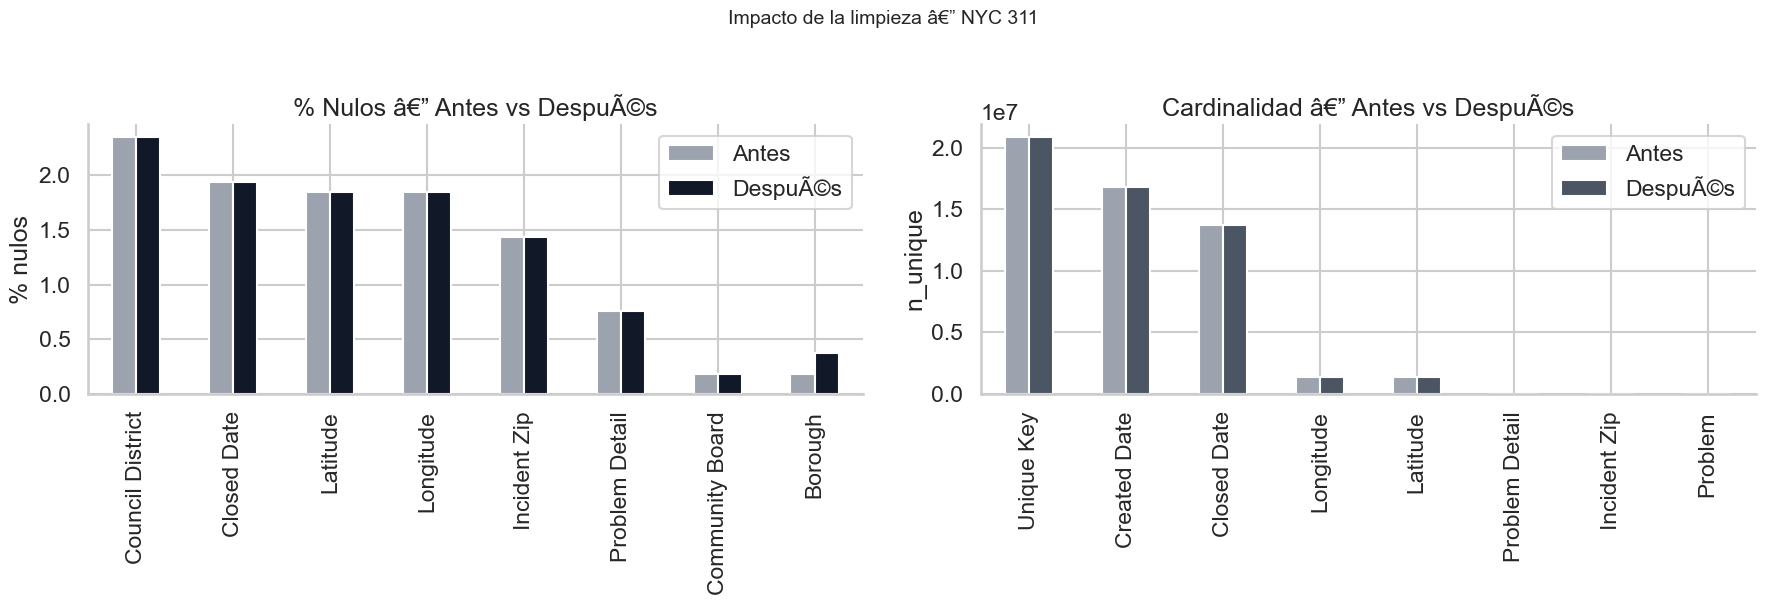

In [17]:
# GrÃ¡fico comparativo de nulos y cardinalidad
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

comparison.sort_values('missing_pct_before', ascending=False).head(8).plot(
    kind='bar',
    y=['missing_pct_before', 'missing_pct_after'],
    ax=axes[0],
    title='% Nulos â€” Antes vs DespuÃ©s',
    color=['#9ca3af', '#111827'],
    ylabel='% nulos',
)
axes[0].set_xlabel('')
axes[0].legend(['Antes', 'DespuÃ©s'])

comparison.sort_values('n_unique_before', ascending=False).head(8).plot(
    kind='bar',
    y=['n_unique_before', 'n_unique_after'],
    ax=axes[1],
    title='Cardinalidad â€” Antes vs DespuÃ©s',
    color=['#9ca3af', '#4b5563'],
    ylabel='n_unique',
)
axes[1].set_xlabel('')
axes[1].legend(['Antes', 'DespuÃ©s'])

plt.suptitle('Impacto de la limpieza â€” NYC 311', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cleaning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. BitÃ¡cora de transformaciones

La limpieza no se considera completa hasta que puede explicarse. Esta bitÃ¡cora documenta cada campo afectado, el problema observado, la regla aplicada y el impacto medido. Es el artefacto que permite reproducir y defender cada decisiÃ³n.


In [18]:
cleaning_log_df = pd.DataFrame(cleaning_log)
cleaning_log_df

,field,problem,rule,impact
0,Created Date / Closed Date,dtype object â€” fechas sin parsear,"pd.to_datetime(errors=""coerce"") aplicado en ca...","Habilitado cÃ¡lculo temporal; 404,928 fechas d..."
1,Created Date â†’ year / month / day_of_week / ...,fecha en bruto â€” no usable directamente en T...,dt.year / dt.month / dt.day_name() / dt.hour /...,6 campos derivados; 0 registros fuera de rango...
2,resolution_hours / resolution_days,campo derivado no existe en raw; valores negat...,Closed Date - Created Date; negativos y > 5 aÃ...,"46,334 negativos + 1,396 extremos invalidados"
3,Borough,"""Unspecified"" como categorÃ­a invÃ¡lida; mayÃº...","str.strip().str.title(); replace(""Unspecified""...","77,142 registros sin borough vÃ¡lido â†’ NaN"
4,Latitude / Longitude,dtype str; separador decimal con coma; coorden...,"str.replace("","", "".""); pd.to_numeric; bounding...","386,513 coordenadas invÃ¡lidas â†’ NaN; dtype ..."
5,Incident Zip,"dtype object; valores como ""11420.0""; ZIPs de ...","strip + remove "".0"" + extract 5 dÃ­gitos con r...",Cardinalidad reducida a 639 ZIPs vÃ¡lidos
6,Agency,posible variaciÃ³n de capitalizaciÃ³n / espacios,str.strip().str.upper(),cardinalidad 21 â†’ 21
7,Status,posible variaciÃ³n de capitalizaciÃ³n / espacios,str.strip().str.upper(),cardinalidad 8 â†’ 8
8,Open Data Channel Type,posible variaciÃ³n de capitalizaciÃ³n / espacios,str.strip().str.upper(),cardinalidad 5 â†’ 5
9,Unique Key (filas),posibles duplicados por carga por chunks,"drop_duplicates(subset=[""Unique Key""])",0 filas eliminadas


---
## 6. VerificaciÃ³n de integridad pre-exportaciÃ³n

Antes de exportar, confirmamos que el dataset limpio cumple las condiciones mÃ­nimas para conectarse a Tableau sin ambigÃ¼edades de tipo.


In [19]:
print('=== VERIFICACIÃ“N DE INTEGRIDAD ===')
print(f'\nShape final: {df.shape}')
print(f'Filas totales: {len(df):,}')
print(f'Columnas: {df.shape[1]}')

print('\nDtypes finales:')
print(df.dtypes)

print('\nNulos por columna (%):')
null_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print(null_pct[null_pct > 0])

# Checks crÃ­ticos
assert df['Unique Key'].nunique() == len(df), 'ERROR: hay Unique Keys duplicados'
assert df['Created Date'].dtype == 'datetime64[us]', 'ERROR: Created Date no es datetime'
assert df['Latitude'].dtype == 'float64', 'ERROR: Latitude no es float64'
assert df['year'].astype(int).between(2020, 2026).all(), 'ERROR: hay aÃ±os fuera del rango esperado'

print('\nâœ“ Todos los checks de integridad pasados')

=== VERIFICACIÃ“N DE INTEGRIDAD ===

Shape final: (20855981, 23)
Filas totales: 20,855,981
Columnas: 23

Dtypes finales:
Unique Key                         int64
Created Date              datetime64[us]
Closed Date               datetime64[us]
Agency                          category
Problem                         category
Problem Detail                       str
Borough                         category
Incident Zip                         str
Community Board                 category
Council District                category
Police Precinct                 category
Status                          category
Open Data Channel Type          category
Latitude                         float64
Longitude                        float64
year                            category
month                           category
month_name                      category
day_of_week                     category
hour_of_day                     category
date                      datetime64[us]
resolution_hours  

Council District    2.35
resolution_hours    2.17
resolution_days     2.17
Closed Date         1.94
Longitude           1.85
Latitude            1.85
Incident Zip        1.44
Problem Detail      0.76
Borough             0.37
Community Board     0.18
dtype: float64



âœ“ Todos los checks de integridad pasados


---
## 7. ExportaciÃ³n

Exportamos tres archivos:
- `311_clean.csv` â€” dataset limpio completo, listo para conectar a Tableau
- `cleaning_log.csv` â€” bitÃ¡cora de transformaciones
- `cleaning_comparison.csv` â€” tabla antes vs despuÃ©s para documentaciÃ³n del portafolio

Usamos `save_for_tableau` del mÃ³dulo `_shared` del curso, que garantiza la ruta de output estructurada por semana.


In [20]:
# Para exportar a CSV con Tableau, convertimos category -> str.
# Se hace in-place sobre `df` (ultima celda del notebook, no se reutiliza)
# para evitar duplicar el DataFrame completo (~20.4M filas) con .copy().
df_export = df
for col in df_export.select_dtypes('category').columns:
    df_export[col] = df_export[col].astype(str).replace('nan', '')

path_clean      = save_for_tableau(df_export, WEEK, '311_clean')
path_log        = save_for_tableau(cleaning_log_df, WEEK, 'cleaning_log')
path_comparison = save_for_tableau(comparison.reset_index(), WEEK, 'cleaning_comparison')

print(f'âœ“ Dataset limpio exportado:  {path_clean}')
print(f'âœ“ BitÃ¡cora exportada:        {path_log}')
print(f'âœ“ ComparaciÃ³n exportada:     {path_comparison}')

âœ“ Dataset limpio exportado:  C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-03-311\311_clean.csv
âœ“ BitÃ¡cora exportada:        C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-03-311\cleaning_log.csv
âœ“ ComparaciÃ³n exportada:     C:\Users\nikole.garcia\Repositorios\DATA-VIZ-PROYECTO\nyc-311-analytics\outputs\week-03-311\cleaning_comparison.csv


---
## 8. ReflexiÃ³n metodolÃ³gica

### Decisiones de limpieza que pueden defenderse

| Problema | Alternativa descartada | DecisiÃ³n tomada | RazÃ³n |
|---|---|---|---|
| Borough = 'Unspecified' | Mantenerlo como categorÃ­a | â†’ NaN | 'Unspecified' no es un borough de NYC; incluirlo distorsionarÃ­a mapas |
| resolution_hours negativos | Tomar valor absoluto | â†’ NaN | No hay base metodolÃ³gica para asumir que el error solo estÃ¡ en el signo |
| Coordenadas fuera del bounding box | Imputar por borough | â†’ NaN | La imputaciÃ³n geoespacial requiere un join externo que introduce supuestos no documentados |
| Problem tiene 272 valores Ãºnicos | Agrupar ahora | Se mantiene sin agrupar | La agrupaciÃ³n es una decisiÃ³n analÃ­tica, no de limpieza; va en el notebook de modelado |

### QuÃ© no se limpiÃ³ (y por quÃ©)

- **`Problem` y `Problem Detail`**: la reducciÃ³n de cardinalidad (272 tipos) no es limpieza â€”es modelado analÃ­tico. Hacerlo aquÃ­ mezclarÃ­a etapas del pipeline.
- **`Closed Date` con 1.9% de nulos**: los registros abiertos o en progreso legÃ­timamente no tienen fecha de cierre. Imputar serÃ­a inventar datos.
- **`Council District`**: tiene 2.3% de nulos pero es un campo de georreferencia secundario. Se mantiene sin imputar; el Borough ya cubre la dimensiÃ³n geogrÃ¡fica principal.

### Lecciones del proceso

- `str.replace(',', '.')` en Latitude/Longitude resolviÃ³ un problema de localizaciÃ³n regional (CSV exportado con configuraciÃ³n de idioma espaÃ±ol)
- La separaciÃ³n entre _limpieza_ (este notebook) y _modelado analÃ­tico_ (siguiente notebook) permite defender cada decisiÃ³n en su capa correcta del pipeline
- El uso de `_shared.py` del curso como referencia garantiza coherencia con los estÃ¡ndares metodolÃ³gicos de la materia
